# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Lau Yan Ler Jovan (2501328E)



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [52]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

# 1. Business Understanding
Goal: Estimate the sale price of a house in King County, USA, based on its physical characteristics and location.

Why this matters: House pricing affects many parties in a property transaction. Sellers want to list at a price that attracts buyers without leaving money on the table. Buyers want to know whether their asking price is fair before committing to an offer. Real estate agents sit between both groups and are often required to justify a listing price quickly, whether to a seller pushing for a higher number or a buyer questioning whether a price is justified. Pricing by experience alone can be slow and hard to defend, especially for agents managing many listings or without years of local pricing intuition. A data-driven price estimate gives all three parties a fast, evidence-based reference point that is most directly useful to the agent, who can use it to support pricing conversations with clients on both sides of a deal.

Type of problem: This is a regression task, because the target variable (price) is a numerical value rather than a category.

Data source: The King County House Sales dataset from Kaggle, containing 21,613 property sales in King County, Washington, recorded between May 2014 and May 2015.

# 2. Data Understanding

## 2.1 Load dataset

In [53]:
## Read *.csv file into pandas DataFrame
FILE_PATH="kc_house_data.csv"
df = pd.read_csv(FILE_PATH)
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


I was wondering why the bathrooms have fractionl values.
I learnt that US property listings count bathrooms in fractions.

1.0	means full bath — toilet, sink, bath/shower
0.75 means three-quarter — toilet, sink, shower (no tub)
0.5	means half bath / powder room — toilet and sink only

So "2.25 bathrooms" = two full baths plus a powder room..

## 2.2 Summary Statistics

In [54]:
## Understand the type of variable for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [55]:
## Check for missing data
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [56]:
## Describe data distribution
df.describe(include='all')

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
unique,NaN,372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,20140623T000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.580302e+09,NaN,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,NaN,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,NaN,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,NaN,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,NaN,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000


In [57]:
## Drop irrelevant columns
df = df.drop(['id', 'date'], axis=1)
## 'id' is just a row identifier - no predictive value
## 'date' is a timestamp string; spec says no pure time-series. plus, all the data is from 2014-2015, so not much predictive value.
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

Text(0.5, 1.0, 'Distribution of price')

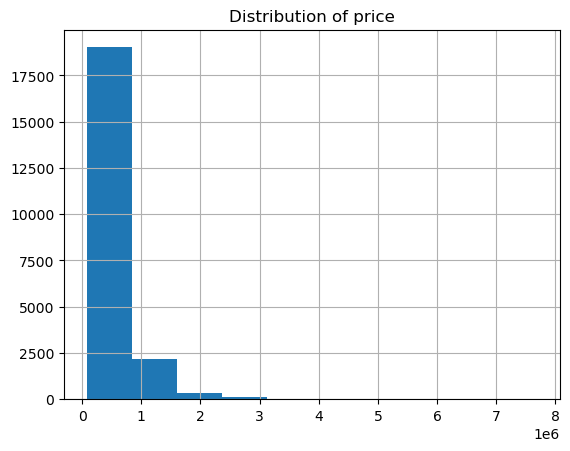

In [58]:
## Understanding distribution of target
col_y = 'price'
df[col_y].hist()
plt.title(f"Distribution of price")

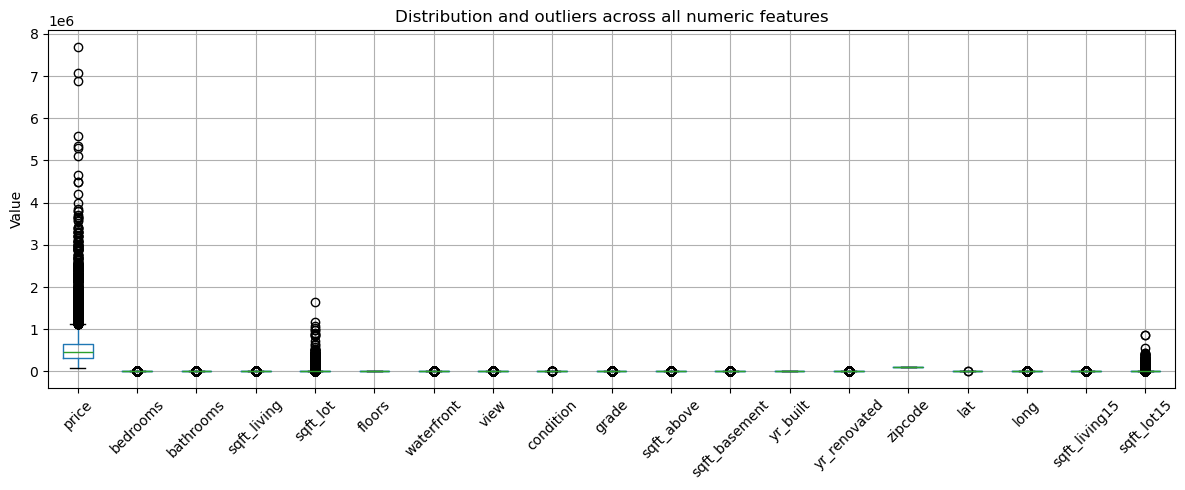

In [59]:
#make boxplot of all columns
df.boxplot(rot=45, figsize=(12, 5))
plt.title('Distribution and outliers across all numeric features')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

The boxplots show that price, sqft_lot and sqft_lot15 carry long upper tails, while bedrooms contains at least one clearly impossible value. The extreme lot sizes are genuine records rather than errors, so they are retained. large rural parcels are a real part of this market. The impossible bedroom count and the zero-bathroom rows will be removed, since a house cannot have 33 bedrooms or no bathroom at all.

In [9]:
col_numeric = df.select_dtypes(include=['float','int']).columns
df_corr = df[col_numeric].corr()
df_corr

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.762704,0.113621,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248


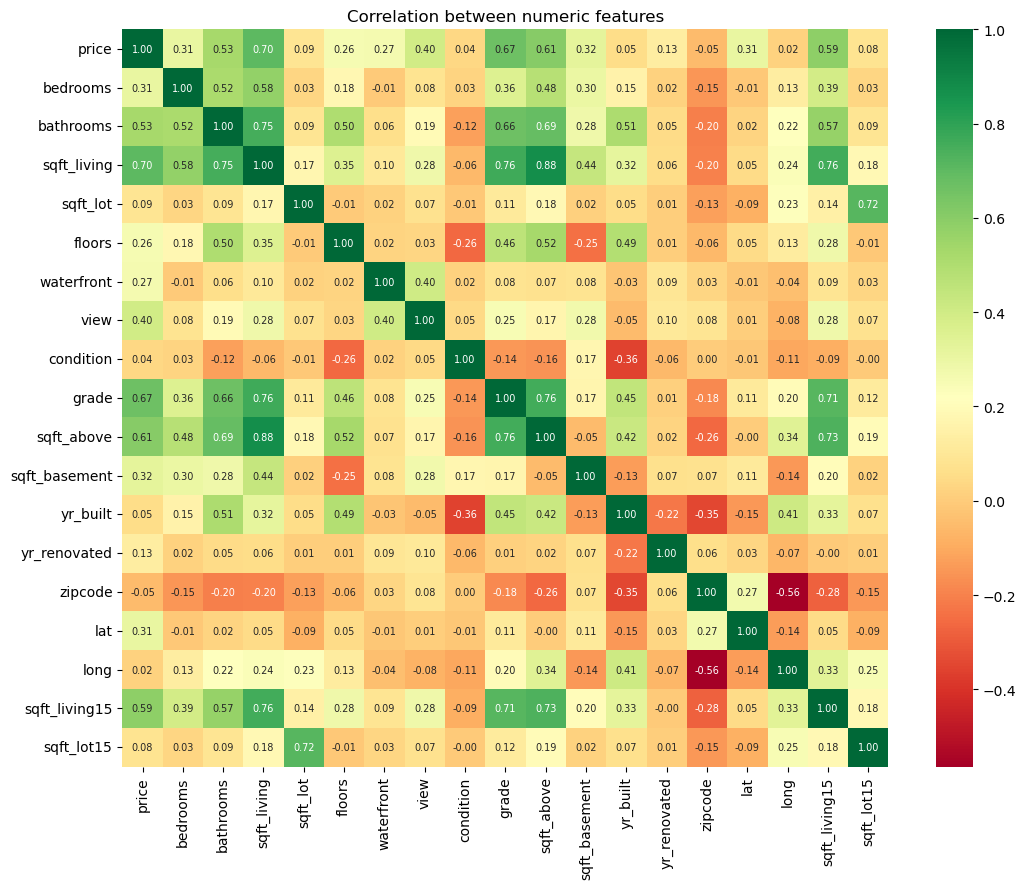

In [60]:
plt.figure(figsize=(11, 9))
sns.heatmap(df_corr, cmap='RdYlGn', annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation between numeric features')
plt.tight_layout()
plt.show()

The features most strongly correlated with price are sqft_living (0.70), grade (0.67), and sqft_above (0.61) — all measures of a property's size and build quality. This aligns with real-world intuition: larger homes and higher-quality construction command higher prices, so these are the primary drivers of value in the King County market.
We expect these size and quality features to rank highest in the model's feature importance. If they don't, it would signal a data or preprocessing problem worth investigating.

I saw that latitude correlates with price (+0.31) while longitude barely does (+0.02), despite both being location features.
I did my research and learnt that in King County, USA, property values follow a north–south gradient. Affluent areas like Seattle, Bellevue and Mercer Island sit to the north, while more affordable districts lie to the south. Latitude therefore tracks price, whereas the east–west axis has no comparable wealth gradient, leaving longitude weakly correlated on its own.
However, longitude's low individual correlation does not make it useless. A tree-based model can combine latitude and longitude jointly to identify specific neighbourhoods, capturing location value that neither coordinate expresses by itself. Hence both should be retained.

sqft_living and sqft_above are highly correlated with each other (0.88), because above-ground area is a large component of total living area. They largely represent the same information: a home's usable size. Keeping both is a bit redundant rather than additive. For a linear model this redundancy causes multicollinearity, making coefficients unstable and harder to interpret. Tree-based models like Gradient Boosting are unaffected, as they select the more informative feature at each split. Since our final model is tree-based, we can retain both features but note this as a candidate for feature selection if a linear model were used.

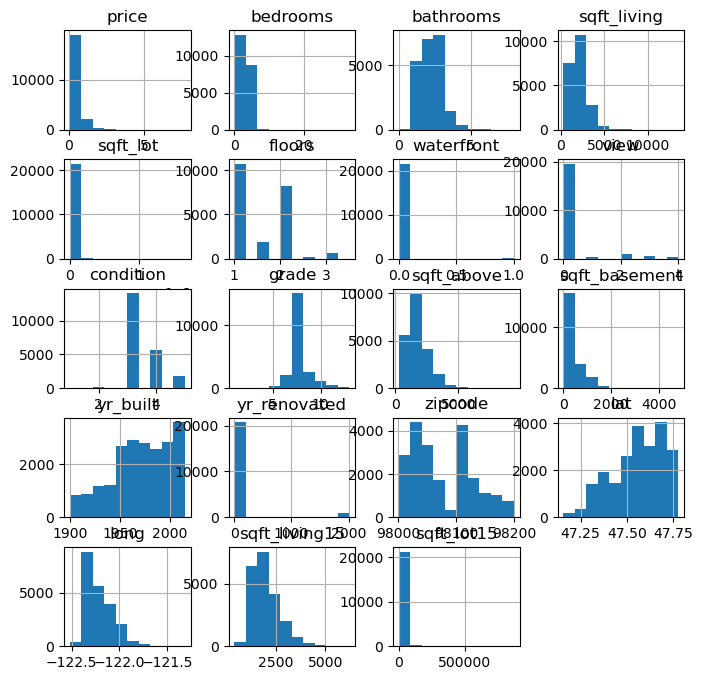

In [11]:
df.hist(figsize=(8, 8))
plt.show()

### 2.3.1.2 Understanding distribution of features

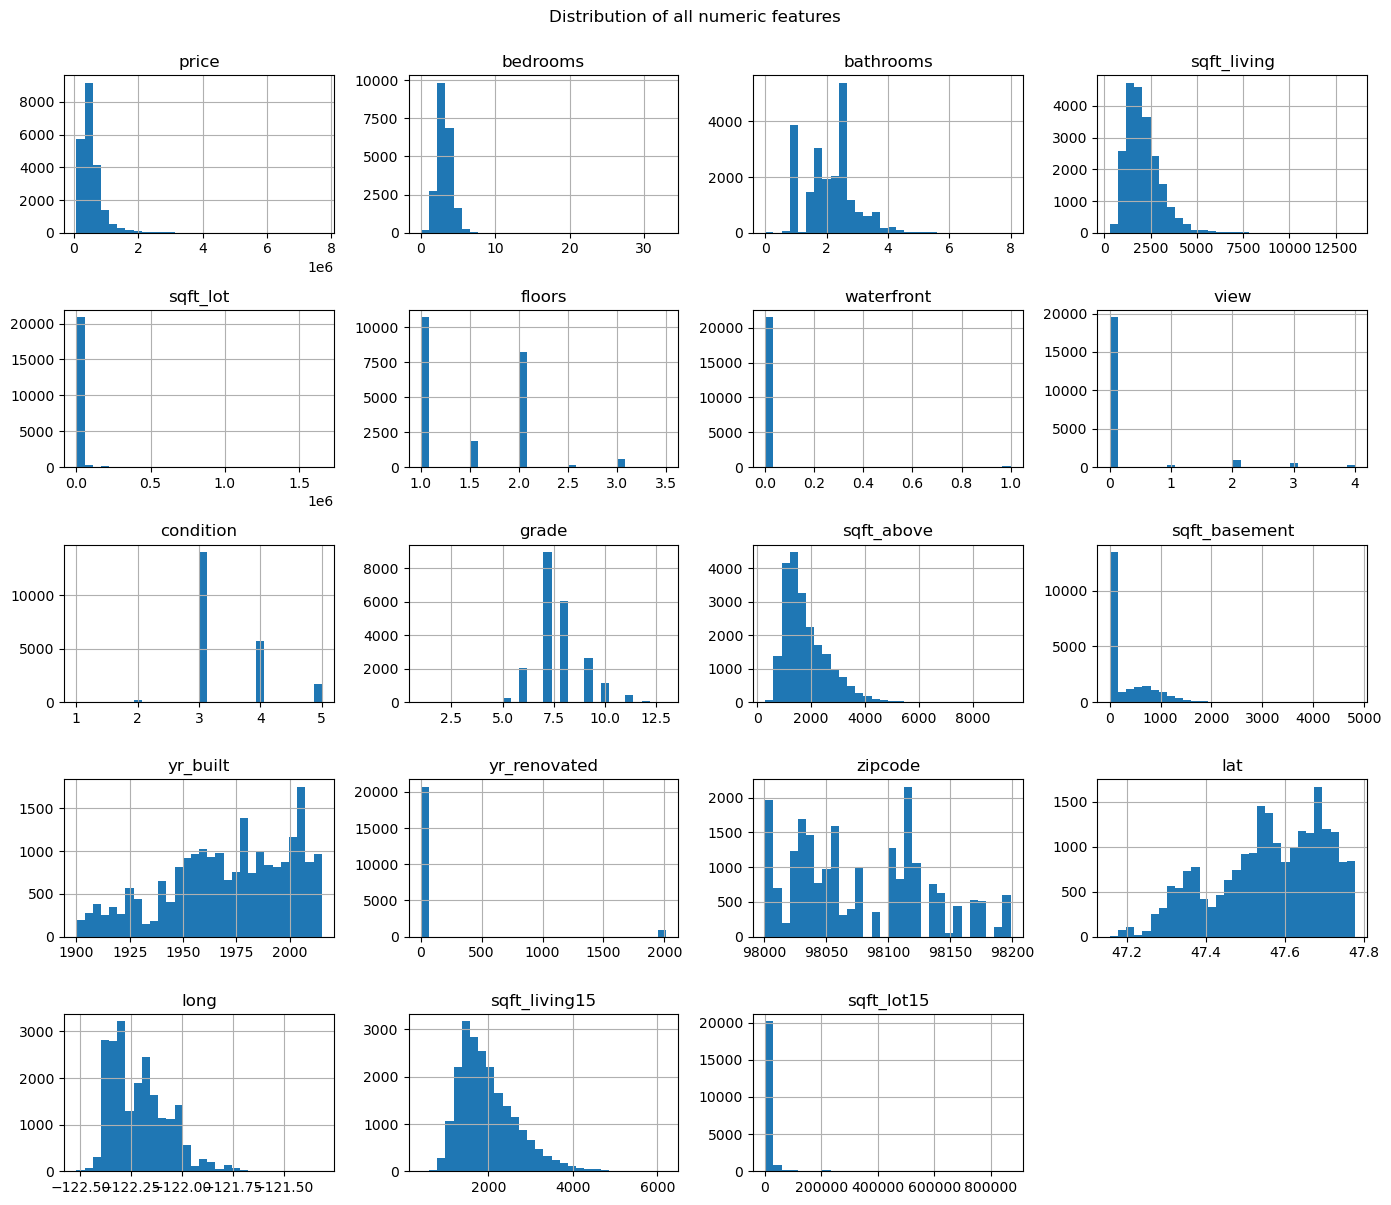

In [65]:
## Understanding distribution of features
df.hist(figsize=(14, 12), bins=30)
plt.suptitle('Distribution of all numeric features', y=1.0)
plt.tight_layout()
plt.show()

### 2.3.2 Understanding relationship between variables

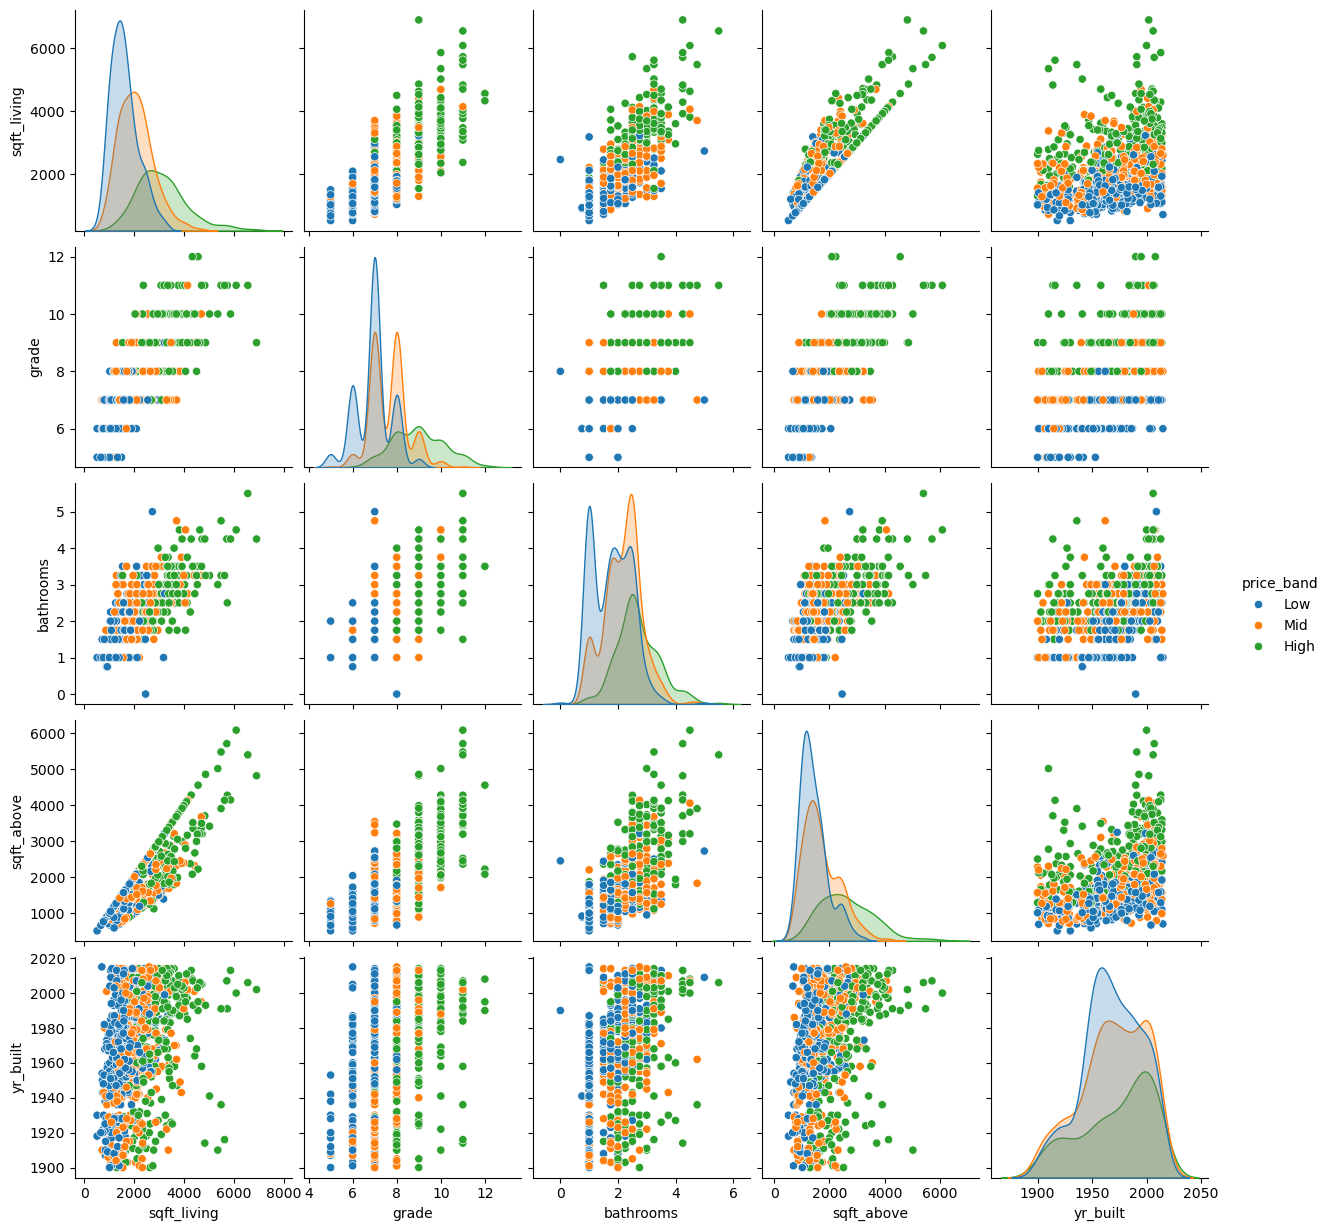

In [13]:
## Understanding relationship between variables
col_y = 'price'

## Bin continuous price into categories so hue is categorical
df["price_band"] = pd.cut(df[col_y],
                          bins=[0, 400000, 700000, 10000000],
                          labels=["Low", "Mid", "High"],
                          include_lowest=True)

## Pairplot on a random sample + key features only - full 21k x 20 is unreadable
col_plot = ['sqft_living', 'grade', 'bathrooms', 'sqft_above', 'yr_built', 'price_band']
sns.pairplot(df[col_plot].sample(1000, random_state=42),
             hue='price_band')
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [14]:
## Clean data
col_categorical = df.select_dtypes(include=['object']).columns  ## Select all categorical columns

## Print data about categorical column
'''
nunique(): Return total number of unique values in column
unique(): Return unique values in column
'''
for col in df[col_categorical]:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()}')

In [15]:
## 1. Remove duplicated rows
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates()

## 2. Fix impossible bedroom count (33 bedrooms in 1,620 sqft with 1.75 baths -> maybe a typo for 3)
df.loc[df['bedrooms'] == 33, 'bedrooms'] = 3

## 3. Remove houses with 0 bedrooms or 0 bathrooms (not habitable -> data errors)
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

print("Rows after cleaning:", len(df))
df

Duplicates found: 5
Rows after cleaning: 21592


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price_band
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,Low
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,Mid
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,Low
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,Mid
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509,Low
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200,Low
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007,Mid
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287,Low


## 4. Modelling (Baseline)

### 4.1.1 Train-Test Split

In [16]:
## only id/date dropped, no encoding, no feature engineering.
## zipcode is left as int64 to see how each model copes.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

col_y = 'price'
y_base = df[col_y]

## price_band is derived from price - drop it, it would leak the target
drop_cols = [col_y] + (['price_band'] if 'price_band' in df.columns else [])
X_base = df.drop(drop_cols, axis=1)   ## zipcode stays as int64 here

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base, y_base, test_size=0.3, random_state=42)

print("Features:", X_base.shape[1])
X_base.dtypes

Features: 18


bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

## 4.1.2 Train Model (4 algorithms)

In [17]:
## Train all four models at default settings
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

baseline_results = []
for name, m in baseline_models.items():
    m.fit(X_train_base, y_train_base)
    pred = m.predict(X_test_base)
    baseline_results.append({
        'Model': name,
        'R2': r2_score(y_test_base, pred),
        'RMSE': root_mean_squared_error(y_test_base, pred),
        'MAE': mean_absolute_error(y_test_base, pred)
    })

baseline_df = pd.DataFrame(baseline_results).sort_values('R2', ascending=False).reset_index(drop=True)
baseline_df

,Model,R2,RMSE,MAE
0,Random Forest,0.883714,128606.784884,69814.623958
1,Gradient Boosting,0.876164,132715.866776,78008.061912
2,Decision Tree,0.774338,179155.042444,98544.768370
3,Linear Regression,0.710331,202978.770941,125520.701878


# 4.1.3 Evaluation

# Linear Regression
Linear Regression achieves the weakest baseline result, with an R² of 0.7103 and a mean absolute error of $125,521. This is expected: `zipcode` is still stored as `int64` at this stage, so a linear model treats it as a single numeric magnitude rather than a category, and cannot represent that different zipcodes shift price independently. This limitation is addressed in Iteration 1.
# Decision Tree
The Decision Tree improves on Linear Regression (R² 0.7743, MAE $98,545), since it can split on `zipcode` directly rather than treating it as one continuous scale. However, a single unpruned tree tends to overfit the training data, limiting how well it generalises.
# Random Forest
Random Forest performs considerably better (R² 0.8837, MAE $69,815), as averaging many trees reduces the overfitting seen in the single Decision Tree. It achieves both the highest R² and the lowest MAE of the four baseline models, even before any feature engineering or tuning.
# Gradient Boosting 
Gradient Boosting is close behind (R² 0.8762, MAE $78,008), but does not beat Random Forest on either metric at this stage. Random Forest is therefore the model carried forward over GB for tuning and into the later iterations.

## Baseline model comparison, ranked
Across the four baseline models, Random Forest performs best on both R² (0.8837) and MAE ($69,815), followed by Gradient Boosting (R² 0.8762, MAE $78,008). Linear Regression performs worst by a clear margin (R² 0.7103), which is
expected given `zipcode` is still stored as `int64` and cannot be used meaningfully by a linear model.

Three problems limit every model at this stage:

1. `zipcode` is a location label stored as a number, so models that rely on
   numeric ordering (Linear Regression in particular) cannot use it properly.
2. `yr_renovated` uses 0 to represent "never renovated", which is read as the
   literal year 0 rather than a meaningful category.
3. No hyperparameter tuning has been applied — all four models are using
   scikit-learn's default settings.

Our winner, Random Forest is tuned below to address problem 3, then carried forward into Iteration 1, where `zipcode` is one-hot encoded and two new features are engineered to address problems 1 and 2.

### Choice of evaluation metrics

This is a regression problem, so classification metrics like accuracy or
F1 do not apply since there are no classes to get right or wrong, only a distance
between the predicted and actual price. I used 3 complementary metrics:

- **MAE** is the headline metric. It is expressed in dollars, so it answers
  the question the estate agent actually asks: how far off is this estimate
  likely to be? It also weights every dollar of error equally, which suits a
  tool used mostly on typical homes rather than outliers.
- **RMSE** squares errors before averaging, so it penalises large misses far
  more heavily. Reported next to MAE it works as a diagnostic: RMSE (~$127k)
  is roughly 1.8x MAE (~$69k), confirming that a minority of expensive
  properties absorb most of the total error — consistent with the
  right-skewed price distribution seen in 2.3.1.1.
- **R²** is scale-free and is used only to compare models against each other
  and against the baseline. On its own it says nothing about dollars, which
  is why it is not the headline metric.

**In business terms:** an MAE of about $69,000 against a mean sale price of
roughly $540,000 means a typical estimate lands within about 13% of the true
price. That is close enough to anchor a pricing conversation and sanity-check
a seller's expectations, but not precise enough to set a final listing price
without the agent's local judgement — which is exactly how the tool is
positioned in Section 1.

# 4.1.4 Hyperparameter Tuning the Best Model

In [18]:
# Hyperparameter Tuning — Baseline's Best Model (Random Forest)
# Tuning is applied at every iteration with the same search space, so any improvement later comes from features, not from tuning.

from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

random_search_base = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1,
)
random_search_base.fit(X_train_base, y_train_base)

best_rf_base = random_search_base.best_estimator_
best_rf_base_pred = best_rf_base.predict(X_test_base)

## Before and after comparison
rf_default = RandomForestRegressor(random_state=42).fit(X_train_base, y_train_base)
rf_default_pred = rf_default.predict(X_test_base)

r2_before = r2_score(y_test_base, rf_default_pred)
r2_after  = r2_score(y_test_base, best_rf_base_pred)
mae_before = mean_absolute_error(y_test_base, rf_default_pred)
mae_after  = mean_absolute_error(y_test_base, best_rf_base_pred)

print("Best parameters:", random_search_base.best_params_)
print()
print(f"{'':30} {'Before':>10} {'After':>10} {' Difference':>10}")
print(f"{'R2':30} {r2_before:>10.4f} {r2_after:>10.4f} {r2_after-r2_before:>+10.4f}")
print(f"{'MAE ($)':30} {mae_before:>10,.0f} {mae_after:>10,.0f} {mae_after-mae_before:>+10,.0f}")

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20}

                                   Before      After  Difference
R2                                 0.8837     0.8861    +0.0024
MAE ($)                            69,815     69,321       -493


Tuning the baseline Random Forest with `RandomizedSearchCV` (n_estimators 200, min_samples_split 5, max_depth 20) improves R² from 0.8837 to 0.8861 and reduces MAE from $69,815 to $69,321. gain of +0.0024 R² and loss of $493 MAE.

The same search space is reused at every later iteration. Because the baseline is tuned too, any improvement in Iteration 1 or 2 is attributable to the features rather than to one stage simply receiving more search effort.

# Iterative model development
## 4.2 Iteration 1 (Handling Categorical Data + Feature Engineering)

### 4.2.1 Handling Categorical Data (One-Hot Encoding of Zipcode)

In [19]:
## zipcode is a location label, not a quantity — cast to string so it is treated as categorical when the features are encoded
df['zipcode'] = df['zipcode'].astype(str)
print(df['zipcode'].nunique(), "unique zipcodes")

70 unique zipcodes


`zipcode` was identified in the Baseline Comparison as a problem: stored as
`int64`, it was being treated as a numeric magnitude rather than a category.
Casting it to a string before one-hot encoding lets each zipcode become its
own binary feature, so the model can learn a separate price effect per
neighbourhood instead of assuming a meaningless numeric ordering.

### 4.2.2 Feature Engineering

In [20]:
## house_age: a more directly interpretable form of yr_built
df['house_age'] = df['yr_built'].max() - df['yr_built']

## is_renovated: yr_renovated uses 0 to mean "never renovated", which the
## model would otherwise read as the literal year 0
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

I made 2 features, house_age, which is how old the house was and is_renovated, if the house has ever gone through renovation. I created house_age as I thought it would be logical for the dataset to show how old the house was, which was surprisingly not in the original dataset.

I created is_renovated as it makes more sense than yr_renovated. yr_renovated uses 0 to represent "never renovated", but the model reads the value as the year 0, which is not true. Converting this feature to a yes/no flag makes more sense.

Then I thought for a while more and added 3 more features. The first is dist_to_downtown, which came directly from something I noticed in my EDA. I saw that latitude correlates with price (+0.31) while longitude barely does (+0.02), which told me the expensive areas run north-south rather than east-west. But latitude on its own only tells the model "further north = pricier", which is a straight line, and that is not really how a city works. Prices radiate outwards from a centre. So I did my research and calculated the distance from each house to downtown Seattle (47.6062, -122.3321) to give the model that in one number instead of making it work it out from 2 features,lat and long, separately. This is also the one feature here that is genuinely new information, unlike house_age which the tree could already get from yr_built.

The second is has_basement. sqft_basement uses 0 to mean "no basement", which is the same problem as yr_renovated. But I think whether a house has a basement at all is a different question from how big it is. A buyer either gets that extra floor or they do not. Converting this feature to a yes/no flag makes more sense.

The third is sqft_vs_neighbours, which is sqft_living divided by sqft_living15 (the average living space of the 15 nearest houses). I wanted this because raw size does not tell you how a house sits in its street. A 2000 sqft house is the big one on a street of 1500 sqft homes, but the small one on a street of 3000 sqft homes, and those two houses would probably not be priced the same way even though sqft_living is identical. This ratio gives the model that context, which neither column gives it alone.

### 4.2.3 Data Preparation for Updated Features

In [21]:
y_i1 = df[col_y]
## price_band was only for the pairplot, I dropped it so it doesn't leak into the model
X_i1 = df.drop([col_y, 'price_band'], axis=1, errors='ignore')
X_i1 = pd.get_dummies(X_i1, drop_first=True)

X_train_i1, X_test_i1, y_train_i1, y_test_i1 = train_test_split(
    X_i1, y_i1, test_size=0.3, random_state=42)

print("Features:", X_i1.shape[1])

Features: 88


### 4.2.4 Random Forest with Encoding + Engineered Features

In [22]:
rf_i1 = RandomForestRegressor(random_state=42)
rf_i1.fit(X_train_i1, y_train_i1)
pred_i1 = rf_i1.predict(X_test_i1)

iter1_df = pd.DataFrame([{
    'Model': 'Random Forest',
    'R2': r2_score(y_test_i1, pred_i1),
    'RMSE': root_mean_squared_error(y_test_i1, pred_i1),
    'MAE': mean_absolute_error(y_test_i1, pred_i1)
}])
iter1_df

,Model,R2,RMSE,MAE
0,Random Forest,0.885677,127516.82744,69264.059101


### 4.2.5 Hyperparameter Tuning for Iteration 1

In [23]:
# Hyperparameter Tuning on the Iteration 1 feature set
# Same search space as before, so any gain is attributable to the features rather than to a wider search.
random_search_i1 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,   # reused from Baseline 4.1.8
    n_iter=10, cv=5, scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1,
)
random_search_i1.fit(X_train_i1, y_train_i1)

best_rf_i1 = random_search_i1.best_estimator_
best_rf_i1_pred = best_rf_i1.predict(X_test_i1)

print("Best parameters:", random_search_i1.best_params_)
print(f"Tuned RF (Iteration 1 features) — R2:  {r2_score(y_test_i1, best_rf_i1_pred):.4f}")
print(f"Tuned RF (Iteration 1 features) — MAE: ${mean_absolute_error(y_test_i1, best_rf_i1_pred):,.0f}")

Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}
Tuned RF (Iteration 1 features) — R2:  0.8861
Tuned RF (Iteration 1 features) — MAE: $68,933


### Comparison of Baseline and Iteration 1 Models
One-hot encoding zipcode and adding house_age/is_renovated produced a small improvement for the default Random Forest: R2 moved from 0.8837 (baseline) to 0.8856 on the engineered features. The gain at default settings is modest, since Random Forest can already split on zipcode as a raw number to some extent — the encoding change matters far less for tree models than it did for Linear Regression in the Baseline comparison, where treating zipcode as a number was a much bigger handicap.

Tuning the Iteration 1 feature set (4.2.5) with the same search space as the baseline brings Random Forest to R2 0.8861 and MAE $68,933. R2 is level with the tuned baseline (0.8861), so the whole gain shows up in MAE, which drops from $69,321 to $68,933. Comparing tuned to tuned keeps this a fair test: any improvement here is attributable to the engineered features rather than to the hyperparameter search having more room to work with.

Speaking of our engineered features, I learnt that the small movement is expected for a tree model. house_age is just a transformation of yr_built, so a split at, for example, "yr_built > 1990" is the identical split as "house_age < 25", so the tree already had that information. The same applies to is_renovated: the tree could already split yr_renovated at 0. However I still think that is_renovated is still worth keeping because it fixes a genuine data problem (the year-zero part), regardless of how much it affected R².

Random Forest is carried forward into Iteration 2, where feature importance is used to identify which of the 88 encoded features are actually contributing to the model.

# 4.3 Iteration 2 (Feature Importance & Feature Selection)

 ## 4.3.1 Feature Importance

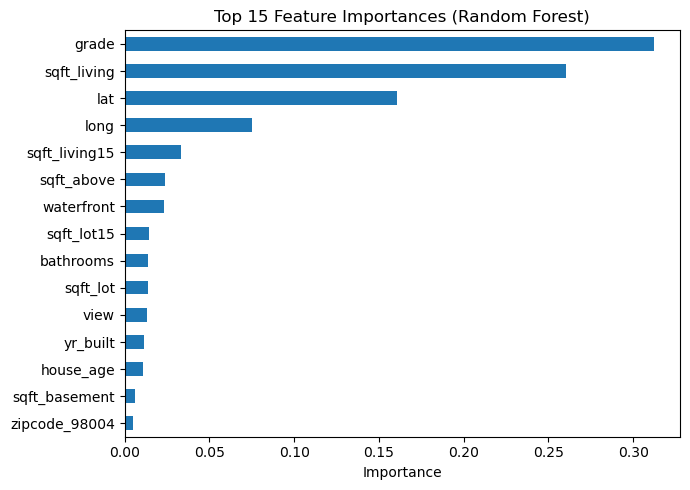

Features with near-zero importance: 62 of 88


In [24]:
## Feature importance from the Random Forest
importances = pd.Series(rf_i1.feature_importances_, index=X_train_i1.columns).sort_values(ascending=False)

importances.head(15).sort_values().plot(kind='barh', figsize=(7,5))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Features with near-zero importance:", (importances < 0.0005).sum(), "of", len(importances))

## 4.3.2 Feature Selection

Using the feature importances from 4.3.1, the top 20 features by importance are selected and the model is retrained on this reduced set. This drops 68 features, 62 of which carry near-zero importance (individually below 0.0005). The test is whether those features are truly uninformative, or whether the ensemble is still extracting value from them in combination — a distinction plain importance scores alone can't answer.

## 4.3.3 Data Preparation for Selected Features

In [25]:
## Keep only the top 20 features by importance, in both train and test sets
top_features = importances.head(20).index

X_train_sel = X_train_i1[top_features]
X_test_sel = X_test_i1[top_features]

print("Selected features:", len(top_features))

Selected features: 20


## 4.3.4 Random Forest with Selected Features

In [26]:
## Retrain Random Forest using only the selected features
rf_sel = RandomForestRegressor(random_state=42)
rf_sel.fit(X_train_sel, y_train_i1)
pred_sel = rf_sel.predict(X_test_sel)

r2_full = r2_score(y_test_i1, rf_i1.predict(X_test_i1))
mae_full = mean_absolute_error(y_test_i1, rf_i1.predict(X_test_i1))
r2_sel = r2_score(y_test_i1, pred_sel)
mae_sel = mean_absolute_error(y_test_i1, pred_sel)

print(f"All {X_train_i1.shape[1]} features  ---> R2: {r2_full:.4f}  MAE: ${mae_full:,.0f}")
print(f"Top {len(top_features)} features    ---> R2: {r2_sel:.4f}  MAE: ${mae_sel:,.0f}")
print(f"Change in R2:  {r2_sel - r2_full:+.4f}")
print(f"Change in MAE: {mae_sel - mae_full:+,.0f}")

All 88 features  ---> R2: 0.8857  MAE: $69,264
Top 20 features    ---> R2: 0.8837  MAE: $69,789
Change in R2:  -0.0020
Change in MAE: +525


## 4.3.5 Hyperparameter Tuning

In [27]:
## Tune Random Forest on the selected feature set, same search space as before
random_search_sel = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=10, cv=5, scoring='neg_mean_squared_error',
    random_state=42, n_jobs=-1,
)
random_search_sel.fit(X_train_sel, y_train_i1)

best_rf_sel = random_search_sel.best_estimator_
best_rf_sel_pred = best_rf_sel.predict(X_test_sel)

print("Best parameters:", random_search_sel.best_params_)
print(f"Tuned RF (selected features) — R2:  {r2_score(y_test_i1, best_rf_sel_pred):.4f}")
print(f"Tuned RF (selected features) — MAE: ${mean_absolute_error(y_test_i1, best_rf_sel_pred):,.0f}")

Best parameters: {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 20}
Tuned RF (selected features) — R2:  0.8852
Tuned RF (selected features) — MAE: $69,462


## 4.3.6 Comparison of Baseline, Iteration 1 and Iteration 2 Models

In [28]:
## Every model tried, across all stages
baseline_df['Stage'] = 'Baseline'
iter1_df['Stage']    = 'Iteration 1'

extra = pd.DataFrame([
    {'Stage': 'Baseline',    'Model': 'Random Forest (tuned)',
     'R2': r2_after, 'RMSE': root_mean_squared_error(y_test_base, best_rf_base_pred),
     'MAE': mae_after},
    {'Stage': 'Iteration 1', 'Model': 'Random Forest (tuned)',
     'R2': r2_score(y_test_i1, best_rf_i1_pred),
     'RMSE': root_mean_squared_error(y_test_i1, best_rf_i1_pred),
     'MAE': mean_absolute_error(y_test_i1, best_rf_i1_pred)},
    {'Stage': 'Iteration 2', 'Model': 'Random Forest (top 20 features, default)',
     'R2': r2_sel, 'RMSE': root_mean_squared_error(y_test_i1, pred_sel),
     'MAE': mae_sel},
    {'Stage': 'Iteration 2', 'Model': 'Random Forest (top 20 features, tuned)',
     'R2': r2_score(y_test_i1, best_rf_sel_pred),
     'RMSE': root_mean_squared_error(y_test_i1, best_rf_sel_pred),
     'MAE': mean_absolute_error(y_test_i1, best_rf_sel_pred)},
])
print('(NOT rank based on R2, just a comparison/summary of all models tried!!!)')
comparison_all = pd.concat([baseline_df, iter1_df, extra], ignore_index=True)
comparison_all = comparison_all[['Stage', 'Model', 'R2', 'RMSE', 'MAE']]
comparison_all

(NOT rank based on R2, just a comparison/summary of all models tried!!!)


,Stage,Model,R2,RMSE,MAE
0,Baseline,Random Forest,0.883714,128606.784884,69814.623958
1,Baseline,Gradient Boosting,0.876164,132715.866776,78008.061912
2,Baseline,Decision Tree,0.774338,179155.042444,98544.768370
3,Baseline,Linear Regression,0.710331,202978.770941,125520.701878
4,Iteration 1,Random Forest,0.885677,127516.827440,69264.059101
5,Baseline,Random Forest (tuned),0.886133,127262.040004,69321.474099
6,Iteration 1,Random Forest (tuned),0.886055,127305.425050,68932.804764
7,Iteration 2,"Random Forest (top 20 features, default)",0.883667,128632.600434,69789.373461
8,Iteration 2,"Random Forest (top 20 features, tuned)",0.885234,127763.628458,69462.349252


Feature selection reduced performance on both R² and MAE. Although 62 of the 88 features individually carry near-zero importance, Random Forest builds many trees from random feature subsets, so even weak features occasionally
contribute in combinations that a single importance ranking does not capture. Dropping them removes information the ensemble was still using in aggregate, even if no single feature stood out.

The full 88-feature Random Forest is therefore retained rather than the reduced version.

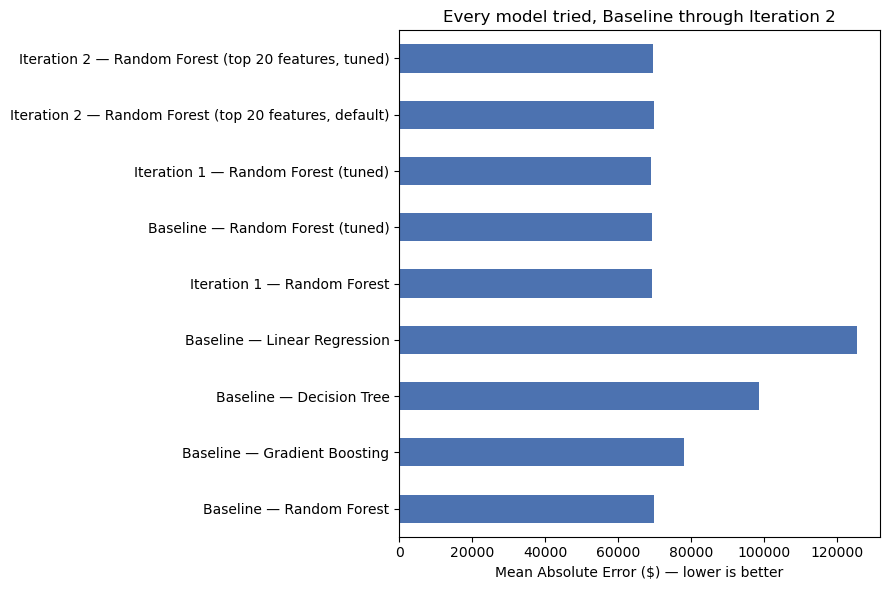

In [29]:
ax = comparison_all.set_index(comparison_all['Stage'] + ' — ' + comparison_all['Model'])[['MAE']].plot(
    kind='barh', figsize=(9, 6), legend=False, color='#4C72B0')
ax.set_xlabel('Mean Absolute Error ($) — lower is better')
ax.set_ylabel('')
plt.title('Every model tried, Baseline through Iteration 2')
plt.tight_layout()
plt.show()

Across all stages, R2 barely moves — every model sits between 0.8837 and 0.8861, a spread of 0.0024. Ranked by MAE the picture is clearer: Iteration 1's tuned Random Forest wins at $68,933, ahead of the tuned baseline at $69,321 and Iteration 2's tuned selection at $69,462.

The honest conclusion is that R2 was close to saturated at baseline. King County prices are largely explained by size, grade and location, and an untuned Random Forest on 18 raw columns already captures nearly all of that. What the iterations bought was a modest but consistent MAE improvement of about $880 from baseline default to Iteration 1 tuned, roughly 1.3%.

Iteration 2 confirmed that feature selection does not help here. Reducing to the top 20 features cost 0.0020 R2 and $525 MAE at default settings, and tuning recovered only part of it. Although 62 of the 88 features carry near-zero individual importance, Random Forest draws a random subset of features at each split, so weak features still contribute in combinations that a single importance ranking cannot capture.

The full-feature, tuned Iteration 1 Random Forest is therefore selected as the final model: best MAE, level on R2, and keeping all 88 features carries no meaningful deployment cost at this dataset size.

## Predicting with new data

In [30]:
new_house = pd.DataFrame([{
    'bedrooms': 3, 'bathrooms': 2.25, 'sqft_living': 2100, 'sqft_lot': 7500,
    'floors': 2.0, 'waterfront': 0, 'view': 0, 'condition': 3, 'grade': 8,
    'sqft_above': 2100, 'sqft_basement': 0, 'yr_built': 1995, 'yr_renovated': 0,
    'zipcode': '98052', 'lat': 47.6740, 'long': -122.1215,
    'sqft_living15': 2000, 'sqft_lot15': 7600,
}])
new_house['house_age']    = df['yr_built'].max() - new_house['yr_built']
new_house['is_renovated'] = (new_house['yr_renovated'] > 0).astype(int)

new_house_enc = pd.get_dummies(new_house, drop_first=True)
new_house_enc = new_house_enc.reindex(columns=X_train_i1.columns, fill_value=0)

print(f"Predicted price: ${best_rf_i1.predict(new_house_enc)[0]:,.0f}")

Predicted price: $558,154


In [63]:
# Finally... we save the Final Model and its training column order for the Streamlit app
import joblib
joblib.dump(best_rf_i1, 'model.pkl')
joblib.dump(X_train_i1.columns.tolist(), 'model_columns.pkl')
print('Saved model.pkl and model_columns.pkl')
## check the saved model and column list agree, since a mismatch would crash the Streamlit app on every prediction.
check_model = joblib.load('model.pkl')
check_cols = joblib.load('model_columns.pkl')
print("Model expects:", check_model.n_features_in_, "features")
print("Saved columns:", len(check_cols))
print("Match?:", check_model.n_features_in_ == len(check_cols))

Saved model.pkl and model_columns.pkl
Model expects: 88 features
Saved columns: 88
Match?: True


Iteration 1's tuned Random Forest is retained as the final model. Both the fitted model and the training column order are saved, since the Streamlit app must build its input row with exactly the same columns, in the same order, that the model was trained on.

# Summary

In [51]:
## Final summary table
summary = comparison_all[comparison_all['Model'].str.contains('Random Forest')].copy()

summary['Features'] = summary['Stage'].map({
    'Baseline': '18 raw',
    'Iteration 1': '88 encoded + engineered',
    'Iteration 2': 'top 20 selected',
})

summary = summary[['Stage', 'Features', 'Model', 'R2', 'RMSE', 'MAE']]
summary = summary.round({'R2': 4, 'RMSE': 0, 'MAE': 0})
best_mae = summary['MAE'].min()

def highlight_best(row):
    if row['MAE'] == best_mae:
        return ['background-color: #197103; color: white'] * len(row)
    return [''] * len(row)
summary.style.apply(highlight_best, axis=1)

,Stage,Features,Model,R2,RMSE,MAE
0,Baseline,18 raw,Random Forest,0.883700,128607.000000,69815.000000
4,Iteration 1,88 encoded + engineered,Random Forest,0.885700,127517.000000,69264.000000
5,Baseline,18 raw,Random Forest (tuned),0.886100,127262.000000,69321.000000
6,Iteration 1,88 encoded + engineered,Random Forest (tuned),0.886100,127305.000000,68933.000000
7,Iteration 2,top 20 selected,"Random Forest (top 20 features, default)",0.883700,128633.000000,69789.000000
8,Iteration 2,top 20 selected,"Random Forest (top 20 features, tuned)",0.885200,127764.000000,69462.000000


This project set out to estimate King County house sale prices from physical and location attributes, as a pricing reference for estate agents, sellers and buyers. It is a regression problem, evaluated primarily on MAE.

Four algorithms were compared at baseline. Linear Regression performed worst (R2 0.7103) because zipcode was stored as an integer and a linear model cannot represent 70 unrelated locations on a single numeric scale. Random Forest led on both metrics and was carried forward.

Iteration 1 one-hot encoded zipcode and added house_age and is_renovated. Iteration 2 tested feature selection, which reduced performance and was rejected. Hyperparameter tuning was applied at every stage using the same RandomizedSearchCV search space, so improvements could be attributed to the features rather than to unequal search effort.

The tuned Iteration 1 Random Forest is deployed. Its MAE of $68,933 against a mean sale price of roughly $540,000 means a typical estimate lands within about 13% of the true price — useful for anchoring a pricing conversation or sanity-checking a seller's expectations, but not a substitute for an agent's judgement on an individual property. The most useful finding was a negative one: R2 was effectively saturated at baseline, and the realistic gain from the full pipeline was a 1.3% reduction in typical dollar error.